<a href="https://colab.research.google.com/github/tasveebyousaf/ma-crossover-strategy/blob/main/ma_strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Strategy Return : 102.1%
Buy & Hold      : 273.5%
Sharpe Ratio    : 0.80
Max Drawdown    : -29.8%
Total Trades    : 27


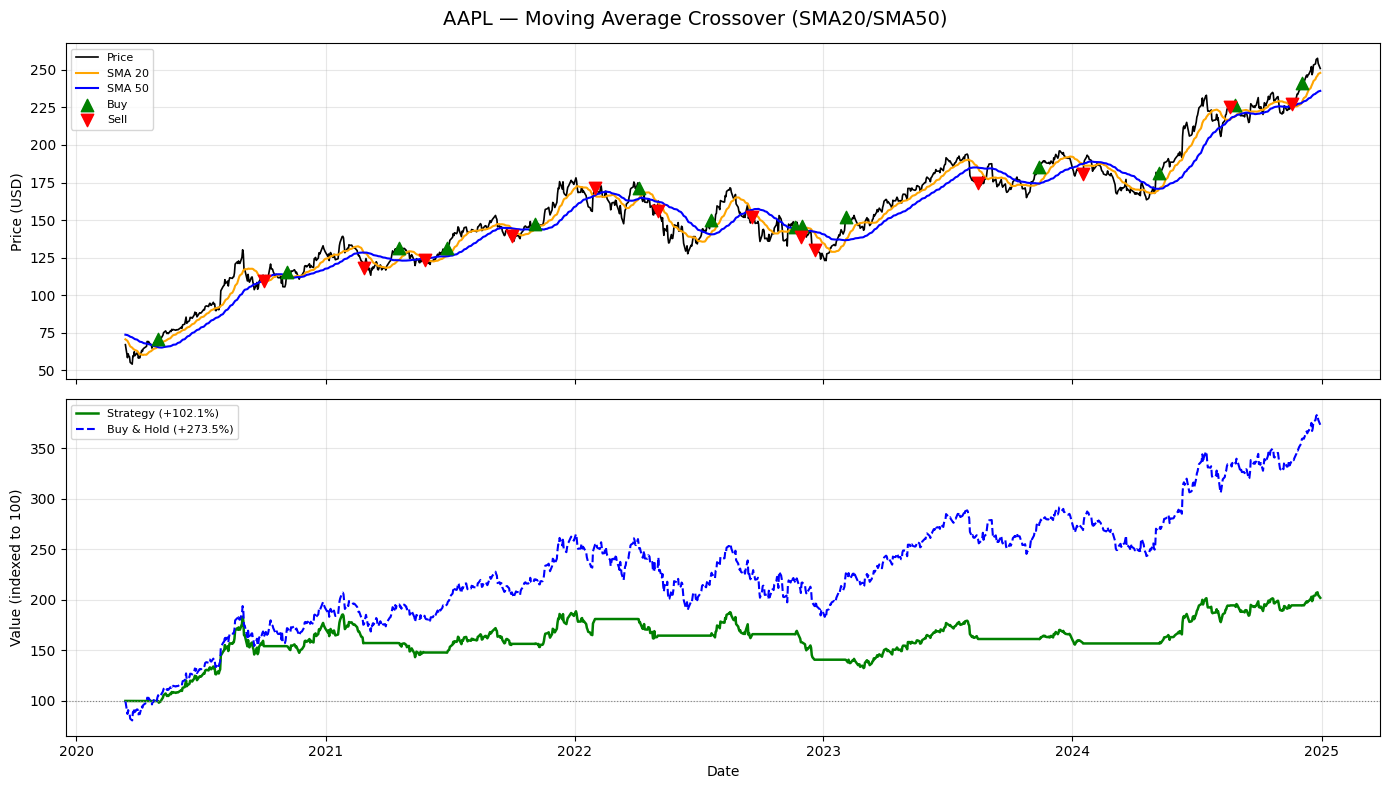

In [1]:
# ============================================================
#  Moving Average Crossover Strategy
# ============================================================

# ── 0. Install & imports ─────────────────────────────────────
!pip install yfinance -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Settings ───────────────────────────────
TICKER     = "AAPL"
START      = "2020-01-01"
END        = "2024-12-31"
SHORT_WIN  = 20       # fast moving average (days)
LONG_WIN   = 50       # slow moving average (days)
CAPITAL    = 10_000   # starting cash ($)
COMMISSION = 0.001    # 0.1% per trade

# ── 2. Download data ─────────────────────────────────────────
df = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)[["Close"]]
df.columns = ["Price"]

# ── 3. Calculate moving averages & signals ───────────────────
df["SMA_Fast"] = df["Price"].rolling(SHORT_WIN).mean()
df["SMA_Slow"] = df["Price"].rolling(LONG_WIN).mean()

# 1 = in market, 0 = out. Signal fires on the change.
df["Position"] = np.where(df["SMA_Fast"] > df["SMA_Slow"], 1, 0)
df["Signal"]   = df["Position"].diff()   # +1 = buy, -1 = sell
df.dropna(inplace=True)

# ── 4. Backtest ───────────────────────────────────────────────
cash, shares = CAPITAL, 0.0
portfolio    = []

for date, row in df.iterrows():
    if row["Signal"] == 1 and cash > 0:                      # BUY
        shares = cash * (1 - COMMISSION) / row["Price"]
        cash   = 0.0
    elif row["Signal"] == -1 and shares > 0:                 # SELL
        cash   = shares * row["Price"] * (1 - COMMISSION)
        shares = 0.0
    portfolio.append(cash + shares * row["Price"])           # daily value

df["Portfolio"] = portfolio

# ── 5. Performance metrics ────────────────────────────────────
final_value  = df["Portfolio"].iloc[-1]
strat_return = (final_value - CAPITAL) / CAPITAL * 100
bah_return   = (df["Price"].iloc[-1] - df["Price"].iloc[0]) / df["Price"].iloc[0] * 100
daily_ret    = df["Portfolio"].pct_change().dropna()
sharpe       = daily_ret.mean() / daily_ret.std() * np.sqrt(252)
max_dd       = ((df["Portfolio"] - df["Portfolio"].cummax()) / df["Portfolio"].cummax()).min() * 100

print(f"Strategy Return : {strat_return:.1f}%")
print(f"Buy & Hold      : {bah_return:.1f}%")
print(f"Sharpe Ratio    : {sharpe:.2f}")
print(f"Max Drawdown    : {max_dd:.1f}%")
print(f"Total Trades    : {int(df['Signal'].abs().sum())}")

# ── 6. Plot ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle(f"{TICKER} — Moving Average Crossover (SMA{SHORT_WIN}/SMA{LONG_WIN})", fontsize=14)

# Panel 1: price + MAs + signals
ax1.plot(df.index, df["Price"],    label="Price",           color="black",  lw=1.2)
ax1.plot(df.index, df["SMA_Fast"], label=f"SMA {SHORT_WIN}",color="orange", lw=1.5)
ax1.plot(df.index, df["SMA_Slow"], label=f"SMA {LONG_WIN}", color="blue",   lw=1.5)
buys  = df[df["Signal"] == 1]
sells = df[df["Signal"] == -1]
ax1.scatter(buys.index,  buys["Price"],  marker="^", color="green", s=80, zorder=5, label="Buy")
ax1.scatter(sells.index, sells["Price"], marker="v", color="red",   s=80, zorder=5, label="Sell")
ax1.set_ylabel("Price (USD)")
ax1.legend(loc="upper left", fontsize=8)
ax1.grid(alpha=0.3)

# Panel 2: strategy vs buy-and-hold (both indexed to 100)
ax2.plot(df.index, df["Portfolio"] / CAPITAL * 100,          label=f"Strategy ({strat_return:+.1f}%)", color="green", lw=1.8)
ax2.plot(df.index, df["Price"] / df["Price"].iloc[0] * 100,  label=f"Buy & Hold ({bah_return:+.1f}%)", color="blue",  lw=1.5, ls="--")
ax2.axhline(100, color="grey", lw=0.8, ls=":")
ax2.set_ylabel("Value (indexed to 100)")
ax2.set_xlabel("Date")
ax2.legend(loc="upper left", fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("ma_strategy_results.png", dpi=150, bbox_inches="tight")
plt.show()